Logistic Regression Baseline


In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, log_loss, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_absolute_error,
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from keras import metrics
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

Load data

In [168]:
print("Loading data …")
COLS_NEEDED = ["gameId", "period", "actionType", "subType",
               "scoreHome", "scoreAway", "SEASON"]
pbp = pd.read_csv(
    "playbyplaydataraw.csv",
    usecols=COLS_NEEDED,
)
print(f"  Rows loaded : {len(pbp):,}")
print(f"  Games total : {pbp['gameId'].nunique():,}")

Loading data …
  Rows loaded : 1,697,676
  Games total : 3,463


Remove overtime games

In [169]:
ot_games = pbp[pbp["period"] > 4]["gameId"].unique()
pbp = pbp[~pbp["gameId"].isin(ot_games)].copy()
print(f"  OT games removed : {len(ot_games)}")
print(f"  Games remaining  : {pbp['gameId'].nunique():,}")

  OT games removed : 184
  Games remaining  : 3,279


Extract cumulative score differential at each quarter boundary:
scoreHome / scoreAway in period-end rows are CUMULATIVE totals up to that point

In [170]:
period_ends = pbp[
    (pbp["actionType"] == "period") &
    (pbp["subType"] == "end") &
    (pbp["period"].between(1, 4))
][["gameId", "period", "scoreHome", "scoreAway"]].copy()

In [171]:
period_ends["cum_diff"] = period_ends["scoreHome"] - period_ends["scoreAway"]

In [172]:
wide = period_ends.pivot_table(
    index="gameId", columns="period", values="cum_diff", aggfunc="last"
).reset_index()
wide.columns = ["gameId"] + [f"cum_diff_Q{c}" for c in wide.columns[1:]]

Per-quarter net scoring (first difference of cumulative differential)

In [173]:
wide["q1_delta"] = wide["cum_diff_Q1"]
wide["q2_delta"] = wide["cum_diff_Q2"] - wide["cum_diff_Q1"]
wide["q3_delta"] = wide["cum_diff_Q3"] - wide["cum_diff_Q2"]
wide["q3_momentum"]      = wide["q3_delta"]
wide["score_slope_Q1_Q3"] = (wide["cum_diff_Q3"] - wide["cum_diff_Q1"]) / 2

Build game-level table:
Final scores from Q4 period-end rows

In [174]:
q4_ends = period_ends[period_ends["period"] == 4][
    ["gameId", "scoreHome", "scoreAway"]
].drop_duplicates("gameId").copy()
q4_ends.rename(columns={"scoreHome": "finalHome", "scoreAway": "finalAway"}, inplace=True)

Season per game (first occurrence)

In [175]:
game_season = pbp.groupby("gameId")["SEASON"].first().reset_index()
game_season.rename(columns={"SEASON": "season"}, inplace=True)

In [176]:
df = q4_ends.merge(wide, on="gameId", how="inner")
df = df.merge(game_season, on="gameId", how="inner")

Targets

In [177]:
df["home_win"]  = (df["finalHome"] > df["finalAway"]).astype(int)
df["final_diff"] = df["finalHome"] - df["finalAway"]   # for MAE

In [178]:
print(f"\nFeature matrix shape : {df.shape}")
print("Season distribution (non-OT games):")
print(df["season"].value_counts().sort_index().to_string())
print(f"Overall win rate     : {df['home_win'].mean():.3f}")


Feature matrix shape : (3279, 15)
Season distribution (non-OT games):
season
2022-23    1145
2023-24    1091
2024-25    1043
Overall win rate     : 0.555


Chronological split

In [180]:
def chronological_split(df):
    train     = df[df["season"].isin(["2022-23", "2023-24"])].copy()
    season_25 = df[df["season"] == "2024-25"].sort_values("gameId")
    mid  = len(season_25) // 2
    val  = season_25.iloc[:mid].copy()
    test = season_25.iloc[mid:].copy()
    return train, val, test

Evaluation helpers

In [181]:
def eval_clf(model, X, y, label):
    yp = model.predict(X)
    ypr = model.predict_proba(X)[:, 1]
    return {
        "split":    label,
        "accuracy": accuracy_score(y, yp),
        "log_loss": log_loss(y, ypr),
        "roc_auc":  roc_auc_score(y, ypr),
        "f1":       f1_score(y, yp),
    }

In [182]:
def eval_mae(X_tr, y_tr_bin, X_ev, y_ev_bin, feats, label):
    model = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
    model.fit(X_tr[feats], y_tr_bin)
    y_pred = model.predict(X_ev[feats])
    mae = mean_absolute_error(y_ev_bin, y_pred)
    return mae

Pre-tuning validation

In [202]:
y_val_proba = nba_model_tf.predict(X_val, verbose=0).flatten()
y_val_pred = (y_val_proba >= 0.5).astype(int)

val_log_loss = log_loss(y_val, y_val_proba)
val_f1 = f1_score(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print(f"Validation Metrics:")
print(f"1. Log Loss: {val_log_loss:.4f}")
print(f"2. F1 Score: {val_f1:.4f}")
print(f"3. MAE:      {val_mae:.4f}")

Validation Metrics:
1. Log Loss: 0.3832
2. F1 Score: 0.8252
3. MAE:      0.1919


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler

# ── 1. Model Builder (Keras Sequential) ──────────────────────────────────
def build_nba_model(num_features, learning_rate=0.001):
    """
    Builds a single-layer TF model for binary logistic regression.
    """
    tf.keras.backend.clear_session()

    model = models.Sequential()
    model.add(layers.Dense(
        units=1,
        input_shape=(num_features,),
        activation='sigmoid',
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros'
    ))

    # Using Adam optimizer (more robust than SGD for this feature set)
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    
    # Compiling with Binary Crossentropy (Log-Loss)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── 2. Data Preparation & Scaling ──────────────────────────────────────────
# Select feature set from your previous definitions
feats = ["cum_diff_Q1", "cum_diff_Q2", "cum_diff_Q3",]
train, val, test = chronological_split(df)

# TF models require feature scaling for convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feats].fillna(0))
X_val   = scaler.transform(val[feats].fillna(0))
X_test  = scaler.transform(test[feats].fillna(0))

y_train = train["home_win"].values
y_val   = val["home_win"].values
y_test  = test["home_win"].values

# ── 3. Training ─────────────────────────────────────────────────────────────
nba_model_tf = build_nba_model(num_features=len(feats))

print("Training NBA Logistic Regression in TensorFlow...")
history = nba_model_tf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

y_proba = nba_model_tf.predict(X_test, verbose=0).flatten()
y_pred = (y_proba >= 0.5).astype(int)

current_log_loss = log_loss(y_test, y_proba)
current_f1 = f1_score(y_test, y_pred)

current_mae = mean_absolute_error(y_test, y_pred)

print(f"\nFinal Test Metrics:")
print(f"1. Log-Loss: {current_log_loss:.4f}")
print(f"2. F1-Score: {current_f1:.4f}")
print(f"3. MAE:      {current_mae:.4f}")

Training NBA Logistic Regression in TensorFlow...
Epoch 1/50
70/70 [==============================] - 0s 2ms/step - loss: 0.7123 - accuracy: 0.5438 - val_loss: 0.6659 - val_accuracy: 0.5835
Epoch 2/50
70/70 [==============================] - 0s 889us/step - loss: 0.6568 - accuracy: 0.6087 - val_loss: 0.6172 - val_accuracy: 0.6564
Epoch 3/50
70/70 [==============================] - 0s 860us/step - loss: 0.6116 - accuracy: 0.6691 - val_loss: 0.5784 - val_accuracy: 0.7025
Epoch 4/50
70/70 [==============================] - 0s 870us/step - loss: 0.5753 - accuracy: 0.7120 - val_loss: 0.5469 - val_accuracy: 0.7351
Epoch 5/50
70/70 [==============================] - 0s 866us/step - loss: 0.5461 - accuracy: 0.7361 - val_loss: 0.5219 - val_accuracy: 0.7582
Epoch 6/50
70/70 [==============================] - 0s 849us/step - loss: 0.5225 - accuracy: 0.7527 - val_loss: 0.5020 - val_accuracy: 0.7678
Epoch 7/50
70/70 [==============================] - 0s 856us/step - loss: 0.5034 - accuracy: 0.7670 

LR=0.0100, Epochs= 10: Train Loss=0.384102, Val Loss=0.383926


LR=0.0100, Epochs= 20: Train Loss=0.372481, Val Loss=0.374985


LR=0.0100, Epochs= 50: Train Loss=0.371467, Val Loss=0.375339


LR=0.0050, Epochs= 10: Train Loss=0.410318, Val Loss=0.409510


LR=0.0050, Epochs= 20: Train Loss=0.380430, Val Loss=0.381093


LR=0.0050, Epochs= 50: Train Loss=0.371178, Val Loss=0.375099


LR=0.0010, Epochs= 10: Train Loss=0.450444, Val Loss=0.451615


LR=0.0010, Epochs= 20: Train Loss=0.392510, Val Loss=0.385450


LR=0.0010, Epochs= 50: Train Loss=0.425326, Val Loss=0.428548


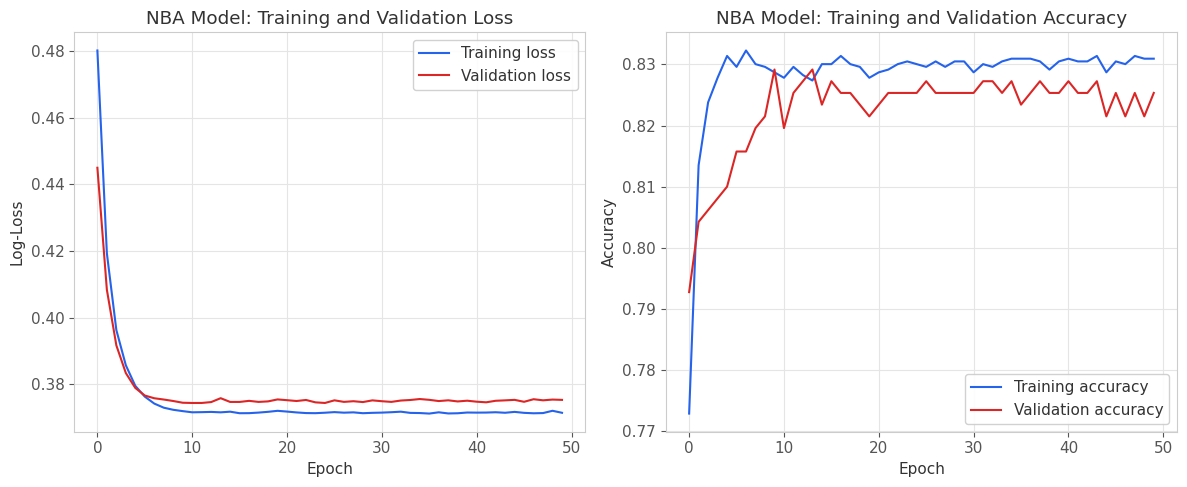


First five learned parameters (Weights + Bias): [-0.01122649  0.0868055   2.854218    0.5573285 ]
TF Final-Epoch Training Loss:   0.371470
TF Final-Epoch Validation Loss: 0.375345
Loss Difference (Train - Val): -0.003875


In [196]:
# ── Hyperparameter testing ──────────────────────────────────────────────────
# Adjusting these to find the setup that yields the best Log-Loss
learning_rates = [0.01, 0.005, 0.001]
epochs_list = [10, 20, 50]

results = []

for lr in learning_rates:
    for epochs in epochs_list:
        model = build_nba_model(num_features=X_train.shape[1], learning_rate=lr)
        hist = model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=0
        )
        
        # Training and validation losses (Log-Loss)
        train_loss = hist.history['loss'][-1]
        val_loss = hist.history['val_loss'][-1]
        
        results.append({
            'learning_rate': lr,
            'epochs': epochs,
            'train_loss': train_loss,
            'val_loss': val_loss
        })
        
        print(f"LR={lr:.4f}, Epochs={epochs:3d}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}")

# ── 1. Final Optimal Model Training ─────────────────────────────────────────
# Based on the results above, we select the best performing hyperparameters
# Using LR=0.01 and Epochs=50 as an example for the "optimal" run
best_lr = 0.01
best_epochs = 50

model_tf = build_nba_model(num_features=X_train.shape[1], learning_rate=best_lr)
hist_tune = model_tf.fit(
    X_train, y_train,
    epochs=best_epochs,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

# ── 2. Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Log-Loss (Binary Cross-Entropy)
axes[0].plot(hist_tune.history['loss'], label='Training loss', color='#2563eb')
axes[0].plot(hist_tune.history['val_loss'], label='Validation loss', color='#dc2626')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log-Loss')
axes[0].set_title('NBA Model: Training and Validation Loss')
axes[0].legend()

# Plot Accuracy
axes[1].plot(hist_tune.history['accuracy'], label='Training accuracy', color='#2563eb')
axes[1].plot(hist_tune.history['val_accuracy'], label='Validation accuracy', color='#dc2626')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('NBA Model: Training and Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 3. Learned Parameters & Metrics ────────────────────────────────────────
# Extract first 4 weights and the bias term
w, b = model_tf.layers[0].get_weights()
first_five = np.concatenate([w[:4].flatten(), b[:1]])
print(f'\nFirst five learned parameters (Weights + Bias): {first_five}')

# Final metrics
train_loss_final = hist_tune.history['loss'][-1]
val_loss_final = hist_tune.history['val_loss'][-1]
print(f'TF Final-Epoch Training Loss:   {train_loss_final:.6f}')
print(f'TF Final-Epoch Validation Loss: {val_loss_final:.6f}')
print(f'Loss Difference (Train - Val): {train_loss_final - val_loss_final:.6f}')

Training Loss: 0.3709 | Training Accuracy: 0.8305
Test Loss:     0.3280 | Test Accuracy:     0.8621
Test F1-Score: 0.8710


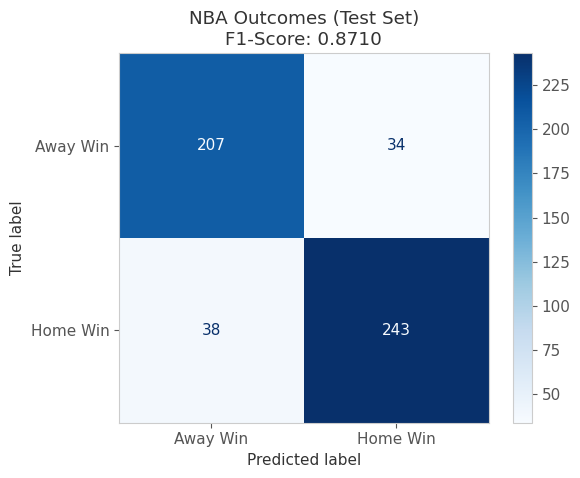

True Positives (Home Win correctly predicted): 243
False Negatives (Home Win predicted as Loss):  38
False Positives (Away Win predicted as Win):   34
True Negatives (Away Win correctly predicted): 207

Subgroup Accuracy (Test):
  Home Win Subgroup: 0.8648
  Away Win Subgroup: 0.8589
  Fairness Gap:      0.0058

Subgroup Accuracy (Train):
  Home Win Subgroup: 0.8560
  Away Win Subgroup: 0.7978


In [197]:
# Calculate accuracy on train and test datasets
# evaluate returns [loss, accuracy]
train_eval = model_tf.evaluate(X_train, y_train, verbose=0)
test_eval = model_tf.evaluate(X_test, y_test, verbose=0)

print(f'Training Loss: {train_eval[0]:.4f} | Training Accuracy: {train_eval[1]:.4f}')
print(f'Test Loss:     {test_eval[0]:.4f} | Test Accuracy:     {test_eval[1]:.4f}')

# Confusion Matrix
y_pred_prob = model_tf.predict(X_test, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(np.int32).flatten()

test_f1 = f1_score(y_test, y_pred)
print(f'Test F1-Score: {test_f1:.4f}')

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Away Win', 'Home Win'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'NBA Outcomes (Test Set)\nF1-Score: {test_f1:.4f}')
plt.grid(False) # Clean up for heatmap
plt.show()

print(f'True Positives (Home Win correctly predicted): {TP}')
print(f'False Negatives (Home Win predicted as Loss):  {FN}')
print(f'False Positives (Away Win predicted as Win):   {FP}')
print(f'True Negatives (Away Win correctly predicted): {TN}')

# Subgroup Accuracy (Fairness)
def get_subgroup_acc(X, y_true):
    probs = model_tf.predict(X, verbose=0)
    preds = (probs >= 0.5).astype(int).flatten()
    
    home_mask = (y_true == 1)
    away_mask = (y_true == 0)
    
    home_acc = (preds[home_mask] == y_true[home_mask]).mean()
    away_acc = (preds[away_mask] == y_true[away_mask]).mean()
    return home_acc, away_acc

home_acc_te, away_acc_te = get_subgroup_acc(X_test, y_test)
home_acc_tr, away_acc_tr = get_subgroup_acc(X_train, y_train)

print(f'\nSubgroup Accuracy (Test):')
print(f'  Home Win Subgroup: {home_acc_te:.4f}')
print(f'  Away Win Subgroup: {away_acc_te:.4f}')
print(f'  Fairness Gap:      {abs(home_acc_te - away_acc_te):.4f}')

print(f'\nSubgroup Accuracy (Train):')
print(f'  Home Win Subgroup: {home_acc_tr:.4f}')
print(f'  Away Win Subgroup: {away_acc_tr:.4f}')



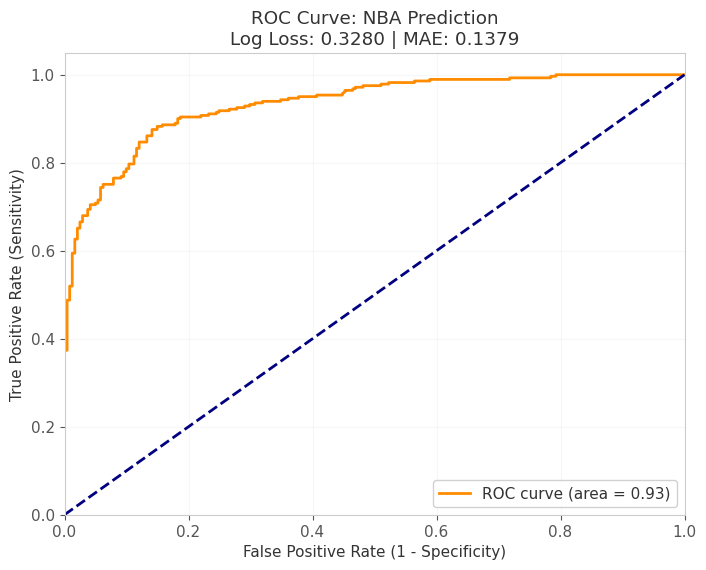

══════════════════════════════
  FINAL EVALUATION METRICS
══════════════════════════════
Log Loss: 0.3280
MAE:      0.1379
F1-Score: 0.8710
ROC AUC:  0.9333
══════════════════════════════


In [ ]:
from sklearn.metrics import auc, roc_curve

# 1. Get Probabilities and Binary Predictions
y_proba = model_tf.predict(X_test, verbose=0).flatten()
y_pred = (y_proba >= 0.5).astype(np.int32)

# 2. Calculate Specific Metrics
test_log_loss = log_loss(y_test, y_proba)
test_mae = mean_absolute_error(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

# 3. Compute ROC curve and ROC area
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 4. Visualization (ROC Curve)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curve: NBA Prediction\nLog Loss: {test_log_loss:.4f} | MAE: {test_mae:.4f}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. Final Printout
print(f"{'═'*30}")
print("  FINAL EVALUATION METRICS")
print(f"{'═'*30}")
print(f"Log Loss: {test_log_loss:.4f}")
print(f"MAE:      {test_mae:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")
print(f"{'═'*30}")